0 / 1000
100 / 1000
200 / 1000
300 / 1000
400 / 1000
=== RESULTADO FILTRO DE KALMAN-KOOPMAN (KKF) ===
Error relativo Depredadores (v) en Bucle Cerrado: 9.45%



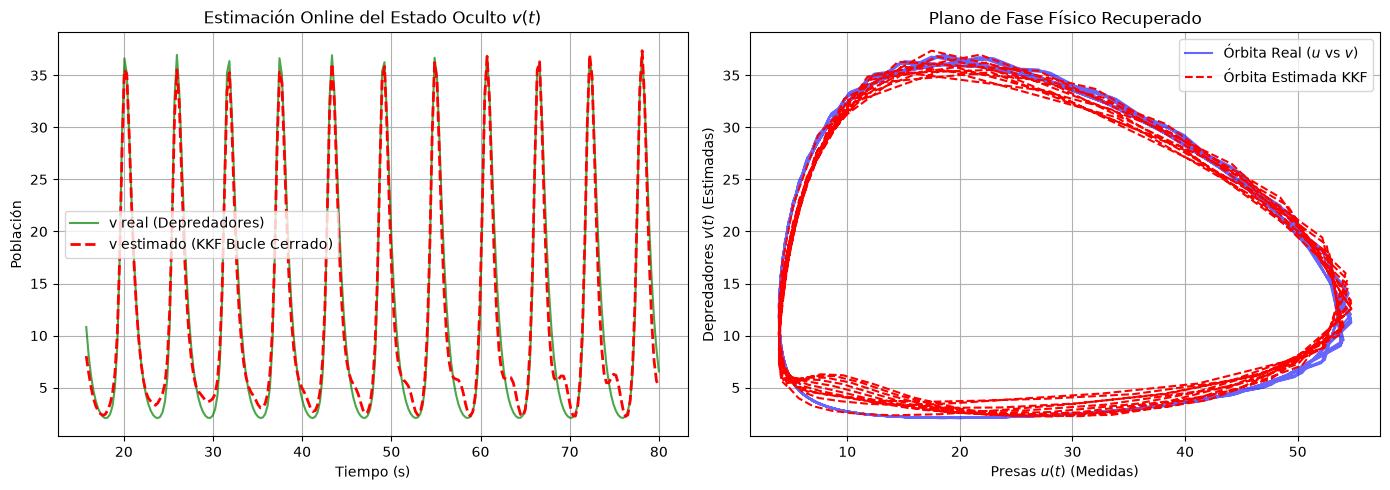

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# 1. INTEGRADOR RK4 PARA LOTKA-VOLTERRA
Nt = 300
T = 80.0
time = np.linspace(0, T, Nt)
dt = time[1] - time[0]

def F(x0, params):
    x = np.zeros((Nt, 2))
    x[0] = x0
    def f(x_val):
        alpha, beta, delta, gamma = params
        x1, x2 = x_val
        return np.array([alpha * x1 - beta * x1 * x2, delta * x1 * x2 - gamma * x2])
    for k in range(Nt-1):
        k1 = f(x[k])
        k2 = f(x[k] + 0.5 * dt * k1)
        k3 = f(x[k] + 0.5 * dt * k2)
        k4 = f(x[k] + dt * k3)
        x[k+1] = x[k] + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
    return x

def build_joint_hankel(u_seq, v_seq, d):
    cols = len(u_seq) - d + 1
    Hu = np.array([u_seq[i : i + d] for i in range(cols)]).T
    Hv = np.array([v_seq[i : i + d] for i in range(cols)]).T
    return np.vstack([Hu, Hv]) # Estado z de dimensión (2d, cols)

# 2. FASE OFFLINE: ENTRENAMIENTO MULTIRRÉGIMEN CON TRUNCADO SVD
np.random.seed(42)
N_sims = 500
d = 60  # Dimensión total del estado z = 50

X1_list, X2_list = [], []
for i in range(N_sims):
    params_i = [
        np.random.uniform(0.8, 1.2),
        np.random.uniform(0.08, 0.12),
        np.random.uniform(0.06, 0.09),
        np.random.uniform(1.2, 1.8)
    ]
    x0_i = [np.random.uniform(6, 15), np.random.uniform(1, 5)]

    x_sim = F(x0_i, params_i)
    Z_sim = build_joint_hankel(x_sim[:, 0], x_sim[:, 1], d)
    X1_list.append(Z_sim[:, :-1])
    X2_list.append(Z_sim[:, 1:])

    if i % 100 == 0:
        print(f"{i} / 1000")

X1 = np.hstack(X1_list)
X2 = np.hstack(X2_list)

# Truncado SVD para limpiar el condicionamiento numérico
# --- 2. FASE OFFLINE: ENTRENAMIENTO MULTIRRÉGIMEN CON TRUNCADO SVD LIMPIO ---
U, s, Vt = np.linalg.svd(X1, full_matrices=False)

r = 40  # Rango óptimo para evitar modos numéricos ruidosos

Ur, sr, Vtr = U[:, :r], s[:r], Vt[:r, :]

# Matriz A_global proyectada correctamente en el subespacio SVD
A_tilde = Ur.T @ X2 @ Vtr.T @ np.diag(1.0 / sr)
A_global = Ur @ A_tilde @ Ur.T

# 3. FASE ONLINE: FILTRO DE KALMAN-KOOPMAN (KKF) EN SISTEMA INÉDITO
params_test = [1.15, 0.095, 0.07, 1.35]
x0_test = [11.0, 2.5]

x_test = F(x0_test, params_test)
u_test_real = x_test[:, 0]
v_test_real = x_test[:, 1]

Z_test = build_joint_hankel(u_test_real, v_test_real, d)
N_steps = Z_test.shape[1]

# Configuraciones del Filtro de Kalman
C_u = np.zeros((1, 2 * d))
C_u[0, d - 1] = 1.0  # Mide únicamente el último punto de la ventana de retardos de u

C_v = np.zeros((1, 2 * d))
C_v[0, 2 * d - 1] = 1.0  # Extrae el valor estimado correspondiente de v

Q = np.eye(2 * d) * 1e-3  # Covarianza del modelo de proceso
R = np.array([[1e-3]])    # Covarianza del ruido de medición de u

z_hat = Z_test[:, 0:1]    # Inicialización del estado estimado
P = np.eye(2 * d) * 1e-2

v_est_kalman = []

# Bucle en tiempo real paso a paso
for k in range(N_steps):
    # Medición escalar real entrante en el paso k
    u_meas = Z_test[d - 1, k]

    # --- 1. PREDICCIÓN (Bucle abierto usando A_global) ---
    z_pred = A_global @ z_hat
    P_pred = A_global @ P @ A_global.T + Q

    # --- 2. CORRECCIÓN (Bucle cerrado usando la medición u_meas) ---
    innovation = u_meas - (C_u @ z_pred)
    S = C_u @ P_pred @ C_u.T + R
    K = P_pred @ C_u.T @ np.linalg.inv(S)

    z_hat = z_pred + K @ innovation
    P = (np.eye(2 * d) - K @ C_u) @ P_pred

    # Guardar la estimación corregida del estado oculto v(t)
    v_est_kalman.append((C_v @ z_hat).item())

# 4. EVALUACIÓN DE RESULTADOS
v_real_aligned = Z_test[2 * d - 1, :]
v_est_kalman = np.array(v_est_kalman)
time_aligned = time[d-1:]

err_v_kkf = (np.linalg.norm(v_real_aligned - v_est_kalman) / np.linalg.norm(v_real_aligned)) * 100

print(f"=== RESULTADO FILTRO DE KALMAN-KOOPMAN (KKF) ===")
print(f"Error relativo Depredadores (v) en Bucle Cerrado: {err_v_kkf:.2f}%\n")

# 5. VISUALIZACIÓN COMPARATIVA
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Serie Temporal
axes[0].plot(time_aligned, v_real_aligned, 'g-', label='v real (Depredadores)', alpha=0.7)
axes[0].plot(time_aligned, v_est_kalman, 'r--', label='v estimado (KKF Bucle Cerrado)', lw=2)
axes[0].set_xlabel('Tiempo (s)')
axes[0].set_ylabel('Población')
axes[0].set_title('Estimación Online del Estado Oculto $v(t)$')
axes[0].legend()
axes[0].grid(True)

# Plano de Fase Físico
axes[1].plot(Z_test[d-1, :], v_real_aligned, 'b-', label='Órbita Real ($u$ vs $v$)', alpha=0.6)
axes[1].plot(Z_test[d-1, :], v_est_kalman, 'r--', label='Órbita Estimada KKF', lw=1.5)
axes[1].set_xlabel('Presas $u(t)$ (Medidas)')
axes[1].set_ylabel('Depredadores $v(t)$ (Estimadas)')
axes[1].set_title('Plano de Fase Físico Recuperado')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()